# Pipeline Training Deteksi Deepfake

In [1]:
# Mengimpor library yang dibutuhkan
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras import layers, models, optimizers
import tensorflow.keras.metrics as metrics
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

# Mematikan pesan log TF yang tidak perlu
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


## 1. Ekstraksi Wajah (MTCNN) & Frame Sampling
Bagian ini membaca video `.mp4`, melakukan frame sampling (mengambil misal 15 frame secara merata dari awal hingga akhir video), dan mendeteksi serta memotong wajah menggunakan MTCNN.

In [2]:
import os
import cv2
import numpy as np
import glob
from mtcnn import MTCNN

def process_video_mtcnn(video_path, label_folder, detector, output_base_dir="Dataset/extracted_faces", num_frames=15, margin=20):
    """
    Fungsi untuk membaca video tunggal, melakukan sampling frame, mendeteksi wajah dengan MTCNN,
    memberikan sedikit margin, dan menyimpannya ke folder dataset.
    """
    detector = MTCNN()
    output_dir = os.path.join(output_base_dir, label_folder)
    os.makedirs(output_dir, exist_ok=True)
    
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Ambil resolusi video untuk batas crop
    v_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    v_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    if total_frames == 0:
        print(f"Gagal membaca video: {video_path}")
        return
        
    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    video_name = os.path.splitext(os.path.basename(video_path))[0]
    saved_count = 0
    
    for idx in tqdm(frame_indices, desc=f"Ekstrak {video_name}", leave=False):
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            continue
            
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = detector.detect_faces(rgb_frame)
        
        if results:
            x, y, w, h = results[0]['box']
            
            # Tambahkan margin dengan memastikan titik koordinat tidak keluar dari dimensi video
            x1 = max(0, x - margin)
            y1 = max(0, y - margin)
            x2 = min(v_width, x + w + margin)
            y2 = min(v_height, y + h + margin)
            
            face_crop = frame[y1:y2, x1:x2]
            
            if face_crop.size != 0:
                # Opsional: Langsung resize ke 299x299 di sini untuk menghemat storage
                # face_crop = cv2.resize(face_crop, (299, 299))
                
                face_filename = f"{video_name}_frame{int(idx)}.jpg"
                face_filepath = os.path.join(output_dir, face_filename)
                cv2.imwrite(face_filepath, face_crop)
                saved_count += 1
                
    cap.release()
    return saved_count    

def process_folder_mtcnn(input_folder, label_folder, output_base_dir="Dataset/extracted_faces", num_frames=15, margin=20):
    """
    Fungsi untuk mencari semua video di dalam folder dan mengekstrak wajahnya.
    """
    # Mencari semua file dengan ekstensi .mp4 di dalam folder target
    search_pattern = os.path.join(input_folder, "*.mp4")
    video_files = glob.glob(search_pattern)
    
    if len(video_files) == 0:
        print(f"Tidak ada file .mp4 yang ditemukan di folder: {input_folder}")
        return
        
    print(f"Ditemukan {len(video_files)} video di '{input_folder}'. Memulai ekstraksi ke folder '{label_folder}'...")

    detector = MTCNN()
    
    print("Memulai ekstraksi dataset...")
    total_wajah_tersimpan = 0
    
    # Looping untuk memproses setiap video satu per satu
    for video_path in tqdm(video_files, desc="Total Progress Folder", unit="video"):
        saved = process_video_mtcnn(video_path, label_folder, detector, output_base_dir, num_frames, margin)
        total_wajah_tersimpan += saved
        
    print(f"\n=== Selesai mengekstrak semua video dari folder {input_folder} ===")

# ==========================================
# CONTOH PENGGUNAAN:
# ==========================================

# 1. Ekstrak folder Asli (Real)
process_folder_mtcnn(input_folder='Dataset/Asli', label_folder='real', num_frames=1)

# 2. Ekstrak folder Palsu/Deepfake (Fake)
process_folder_mtcnn(input_folder='Dataset/Palsu', label_folder='fake', num_frames=1)

Ditemukan 1890 video di 'Dataset/Asli'. Memulai ekstraksi ke folder 'real'...


Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "D:\Skripsi\Backend\env\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "D:\Skripsi\Backend\env\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "D:\Skripsi\Backend\env\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.


Memulai ekstraksi dataset...


Total Progress Folder:   0%|                                                               | 0/1890 [00:00<?, ?video/s]Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "D:\Skripsi\Backend\env\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "D:\Skripsi\Backend\env\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "D:\Skripsi\Backend\env\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.

Total Progress Folder:   0%|                                                       | 1/1890 [00:01<46:28,  1.48s/video]Exception ignored in: <_io.BufferedReader>
Traceback (most rec

KeyboardInterrupt: 

## 2. Penyeimbangan Dataset (Class Weight)
Dataset deepfake sering imbalanced (misal: fake jauh lebih banyak dari real). Daripada membuang data (undersampling), kita bisa menggunakan `class_weight` saat training. Bobot kelas yang jumlahnya sedikit akan diperbesar, sehingga model tidak bias.

In [3]:
def calculate_class_weights(dataset_dir):
    """
    Menghitung bobot kelas untuk mengatasi imbalance dataset.
    Pastikan dataset_dir memiliki struktur sub-folder untuk tiap kelas (misal: /real, /fake).
    """
    classes = sorted(os.listdir(dataset_dir))
    labels = []
    
    print("Statistik Dataset:")
    for i, cls_name in enumerate(classes):
        cls_dir = os.path.join(dataset_dir, cls_name)
        # Menghitung jumlah file/gambar dalam folder
        num_images = len([f for f in os.listdir(cls_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])
        # Membuat list label (contoh: 0 untuk fake, 1 untuk real)
        labels.extend([i] * num_images)
        print(f"- Kelas '{cls_name}': {num_images} gambar")
        
    # Hitung bobot yang seimbang menggunakan scikit-learn
    class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
    weight_dict = dict(enumerate(class_weights))
    
    print(f"\nClass Weights yang akan digunakan: {weight_dict}")
    return weight_dict

# Contoh penggunaan (Pastikan path folder benar saat dieksekusi)
dataset_path = "Dataset/extracted_faces"
class_weight_dict = calculate_class_weights(dataset_path)

Statistik Dataset:
- Kelas 'fake': 9 gambar
- Kelas 'real': 146 gambar

Class Weights yang akan digunakan: {0: np.float64(8.61111111111111), 1: np.float64(0.5308219178082192)}


## 3. Preprocessing & Data Pipeline
Memuat gambar langsung dari direktori secara efisien menggunakan `tf.keras.utils.image_dataset_from_directory`. Sekaligus mengubah ukuran (resize) menjadi 299x299 (standar input Xception) dan menormalisasi nilai piksel ke rentang [-1, 1] menggunakan fungsi bawaan Xception.

In [4]:
IMG_SIZE = (299, 299)
BATCH_SIZE = 32

def create_data_pipeline(dataset_dir):
    """
    Membuat pipeline tf.data.Dataset untuk Training dan Validation.
    """
    print("Memuat Dataset...")
    # Pipeline untuk Data Latih (Training 80%)
    train_ds = tf.keras.utils.image_dataset_from_directory(
        dataset_dir,
        validation_split=0.2,
        subset="training",
        seed=123,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='binary'
    )
    
    # Pipeline untuk Data Validasi (Validation 20%)
    val_ds = tf.keras.utils.image_dataset_from_directory(
        dataset_dir,
        validation_split=0.2,
        subset="validation",
        seed=123,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='binary'
    )
    
    # Menerapkan Preprocessing Input Xception
    # Fungsi preprocess_input bawaan Xception akan menormalisasi piksel dari [0, 255] ke [-1, 1]
    AUTOTUNE = tf.data.AUTOTUNE
    
    train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
    # Cache dan prefetch untuk mempercepat proses training di GPU
    train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
    
    val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
    val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
    
    return train_ds, val_ds

train_dataset, val_dataset = create_data_pipeline(dataset_path)

Memuat Dataset...
Found 155 files belonging to 2 classes.
Using 124 files for training.
Found 155 files belonging to 2 classes.
Using 31 files for validation.


## 4. Pembuatan Arsitektur Model (Xception Murni)
Menggunakan dasar model Xception dengan weights ImageNet, lalu menambahkan custom head (Global Average Pooling, Dropout, dan Dense layer dengan Sigmoid).

In [5]:
def build_xception_classifier():
    """
    Membuat model deteksi deepfake berbasis arsitektur Xception murni.
    """
    # 1. Load arsitektur dasar Xception
    # include_top=False: Membuang layer klasifikasi asli ImageNet (1000 kelas) agar kita bisa memasang head klasifikasi biner
    base_model = Xception(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
    
    # 2. Bekukan (Freeze) bobot layer dasar
    # menjaga fitur ekstraksi yang sudah dipelajari dari ImageNet agar tidak rusak di awal training
    base_model.trainable = False 
    
    # 3. Bangun arsitektur akhir (Custom Head)
    model = models.Sequential([
        base_model,
        
        # Meratakan output 2D dari Xception menjadi vektor 1D
        layers.GlobalAveragePooling2D(),
        
        # Dropout untuk mencegah overfitting dengan menonaktifkan 50% neuron secara acak
        layers.Dropout(0.5),
        
        # Layer Output Biner: 1 Neuron dengan aktivasi Sigmoid
        # Output berupa probabilitas 0.0 s/d 1.0
        layers.Dense(1, activation='sigmoid') 
    ])
    
    return model

model = build_xception_classifier()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ xception (Functional)                │ (None, 10, 10, 2048)        │      20,861,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │           2,049 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,863,529 (79.59 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

## 5. Kompilasi & Metrik Evaluasi
Menentukan optimizer Adam dengan learning rate 1e-4, loss function binary crossentropy, dan metrik Accuracy serta AUC.

In [6]:
# Learning rate 1e-4 umumnya stabil untuk transfer learning
LEARNING_RATE = 1e-4

model.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=[
        'accuracy', 
        metrics.AUC(name='auc') # AUC sangat penting dan representatif untuk klasifikasi biner / imbalanced
    ]
)

print("Model siap dilatih!")

Model siap dilatih!


## 6. Callbacks & Eksekusi Training
Menggunakan `EarlyStopping` untuk mencegah overfitting saat performa validasi berhenti meningkat, serta `ModelCheckpoint` untuk menyimpan model dengan AUC tertinggi secara otomatis.

In [7]:
# Path untuk menyimpan model terbaik
MODEL_SAVE_PATH = 'xception_model.h5'

callbacks = [
    # Early Stopping:
    # monitor='val_loss': Pantau loss pada data validasi
    # patience=5: Toleransi 5 epoch tanpa perbaikan sebelum training dihentikan
    # restore_best_weights=True: Jika berhenti, kembalikan bobot model ke versi yang terbaik
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    
    # Model Checkpoint:
    # Menyimpan model HANYA jika AUC validasi lebih tinggi dari sebelumnya
    ModelCheckpoint(filepath=MODEL_SAVE_PATH, monitor='val_auc', mode='max', save_best_only=True, verbose=1)
]

# ---- BLOK EKSEKUSI TRAINING ----
EPOCHS = 20

print("Memulai proses training...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks
)


Memulai proses training...
Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5420 - auc: 0.3172 - loss: 0.6503
Epoch 1: val_auc improved from None to 0.93333, saving model to best_xception_model.h5



Epoch 1: finished saving model to best_xception_model.h5
4/4 ━━━━━━━━━━━━━━━━━━━━ 39s 7s/step - accuracy: 0.6210 - auc: 0.5366 - loss: 0.7412 - val_accuracy: 0.6452 - val_auc: 0.9333 - val_loss: 0.6448
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6746 - auc: 0.2702 - loss: 0.6414
Epoch 2: val_auc did not improve from 0.93333
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 6s/step - accuracy: 0.6774 - auc: 0.4515 - loss: 0.7626 - val_accuracy: 0.6452 - val_auc: 0.9333 - val_loss: 0.6452
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5605 - auc: 0.3228 - loss: 0.6465
Epoch 3: val_auc did not improve from 0.93333
4/4 ━━━━━━━━━━━━━━━━━━━━ 23s 6s/step - accuracy: 0.5806 - auc: 0.4429 - loss: 0.7854 - val_accuracy: 0.6452 - val_auc: 0.9333 - val_loss: 0.6477
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5856 - auc: 0.5220 - loss: 0.5787
Epoch 4: val_auc did not improve from 0.93333
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 6s/step - accuracy: 0.6290 - auc: 0.6816 - loss: 0.6871


Epoch 6: finished saving model to best_xception_model.h5
4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.5726 - auc: 0.5108 - loss: 0.7504 - val_accuracy: 0.6129 - val_auc: 0.9500 - val_loss: 0.6557
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


## 7. Evaluasi & Visualisasi Confusion Matrix
Melakukan prediksi pada dataset validasi (atau test) dengan threshold 0.5 dan menghasilkan metrik komprehensif serta visualisasi Heatmap.

Memulai prediksi pada dataset...


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:10<00:00, 10.30s/it]



--- Classification Report ---
              precision    recall  f1-score   support

        Fake       0.08      1.00      0.15         1
        Real       1.00      0.63      0.78        30

    accuracy                           0.65        31
   macro avg       0.54      0.82      0.46        31
weighted avg       0.97      0.65      0.76        31



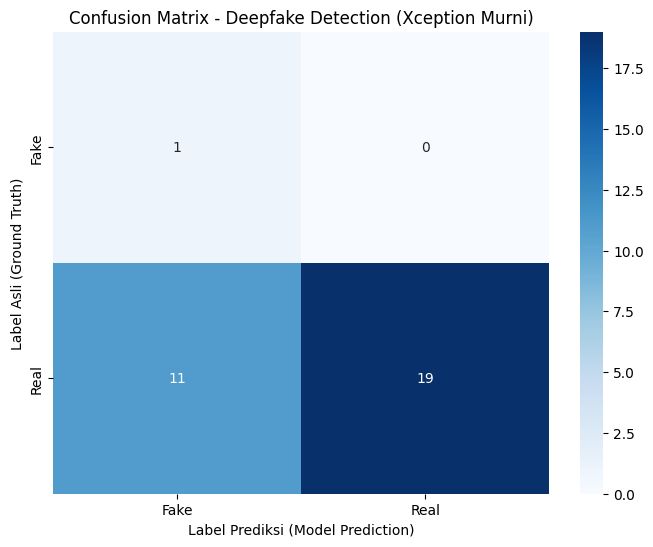

In [9]:
def evaluate_and_plot(trained_model, test_dataset, target_names=['Fake', 'Real']):
    """
    Mengevaluasi model pada data testing/validasi, mencetak Classification Report, 
    dan menampilkan grafik Confusion Matrix menggunakan Seaborn.
    """
    print("Memulai prediksi pada dataset...")
    
    y_pred_probs = []
    y_true = []
    
    # Karena kita menggunakan tf.data.Dataset (yang mengeluarkan batch),
    # kita perlu loop datasetnya untuk mengumpulkan semua prediksi dan label asli.
    for images, labels in tqdm(test_dataset):
        preds = trained_model.predict(images, verbose=0)
        y_pred_probs.extend(preds)
        y_true.extend(labels.numpy())
        
    y_pred_probs = np.array(y_pred_probs).flatten()
    y_true = np.array(y_true).flatten()
    
    # Konversi probabilitas menjadi label kelas dengan batas (threshold) 0.5
    y_pred = (y_pred_probs > 0.5).astype("int32")
    
    # 1. Cetak Classification Report (Akurasi, Precision, Recall, F1-Score)
    print("\n--- Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=target_names))
    
    # 2. Hitung Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # 3. Visualisasi Confusion Matrix menggunakan Seaborn Heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names)
    
    plt.title('Confusion Matrix - Deepfake Detection (Xception Murni)')
    plt.ylabel('Label Asli (Ground Truth)')
    plt.xlabel('Label Prediksi (Model Prediction)')
    plt.show()

# Contoh Eksekusi Evaluasi:
evaluate_and_plot(model, val_dataset)